# Phase 3: Model Interpretability & Latent Space Visualization

## Objective
While our testing metrics ($R^2$, MAE) prove that the LamiGo DeepFM architecture is highly accurate, modern AI systems must also be transparent. In this notebook, we open the "black box" of the neural network to prove that it learned logical, real-world logistics physics.

## Methodology: Dimensionality Reduction
During training, the Factorization Machine assigned an 8-dimensional embedding vector to every unique entity (Drivers, Customers, Locations, Grids). To visualize how the AI "thinks" about these entities, we will extract these trained mathematical weights and apply **t-SNE / UMAP** dimensionality reduction.

By compressing these 8D vectors into a 2D coordinate system, we can observe the natural clustering of sparse categories. If the model successfully learned the environment, we should see high-friction entities (e.g., complex apartment grids) naturally cluster away from low-friction entities (e.g., standard homes), proving the model learned human behavior without explicit human labeling.

In [1]:
# ==========================================
# 1. ENVIRONMENT SETUP
# ==========================================
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import joblib
import warnings

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')

# Set aesthetic styling
sns.set_theme(style="darkgrid", context="talk")
plt.rcParams['figure.figsize'] = (12, 8)

print("✅ Local Visualization Environment Ready.")

✅ Local Visualization Environment Ready.


🧠 Extracting memories from the Local DeepFM Brain...

📊 Generating layout for: driver_id...


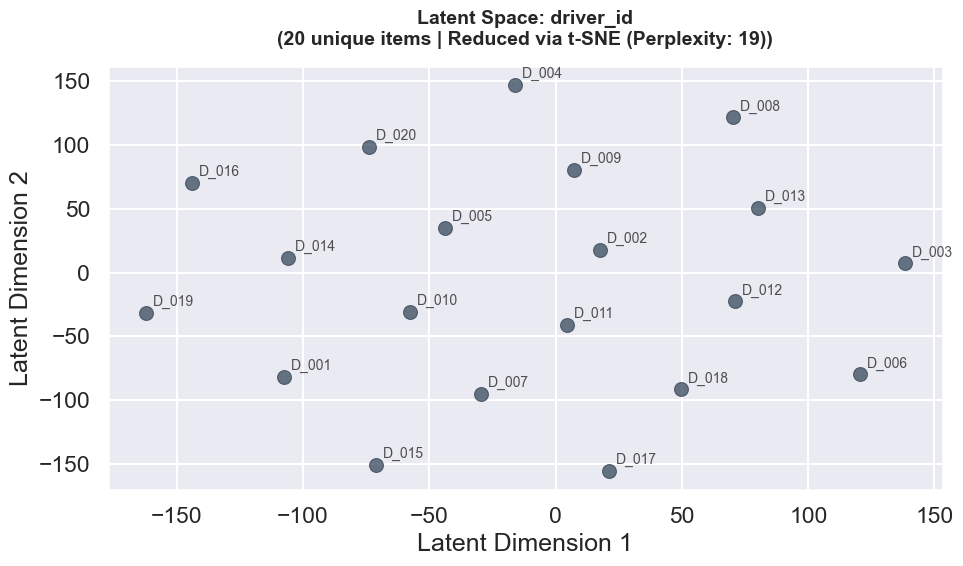

------------------------------------------------------------
📊 Generating layout for: prev_customer_id...


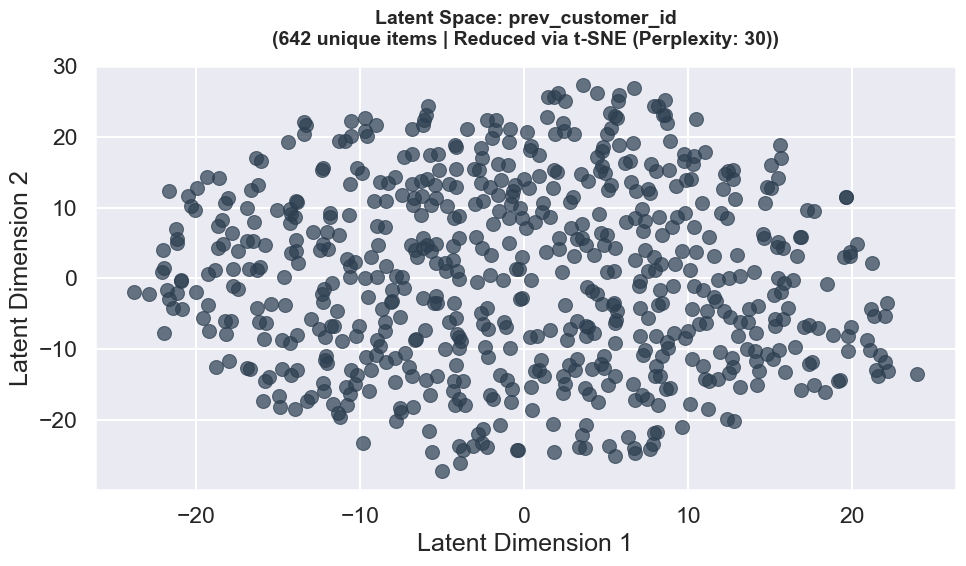

------------------------------------------------------------
📊 Generating layout for: customer_id...


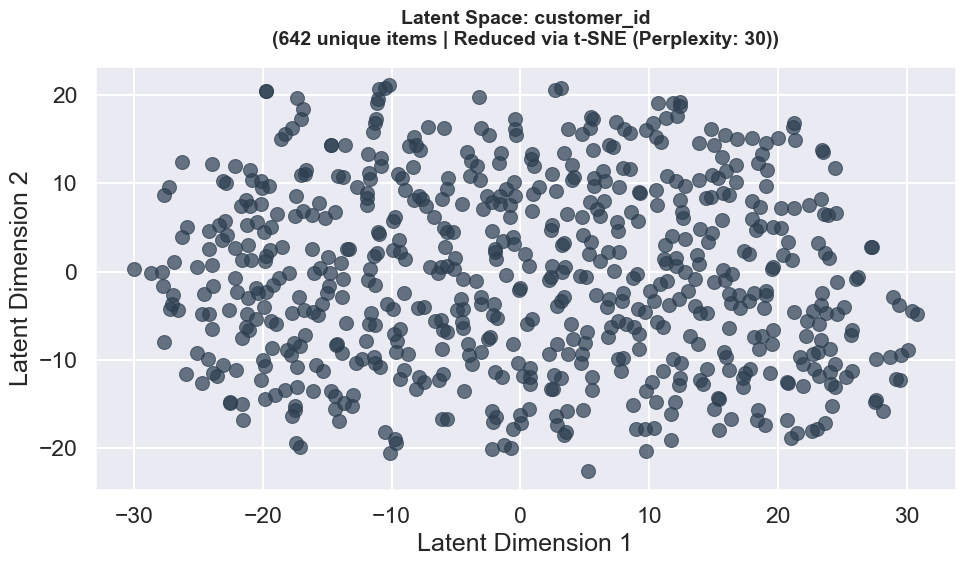

------------------------------------------------------------
📊 Generating layout for: destination_grid_id...


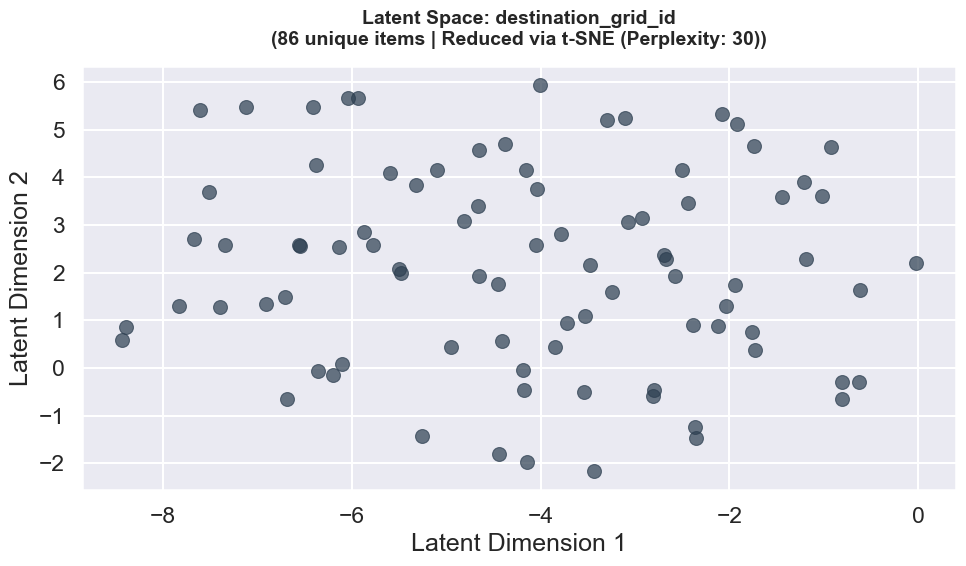

------------------------------------------------------------
📊 Generating layout for: origin_grid_id...


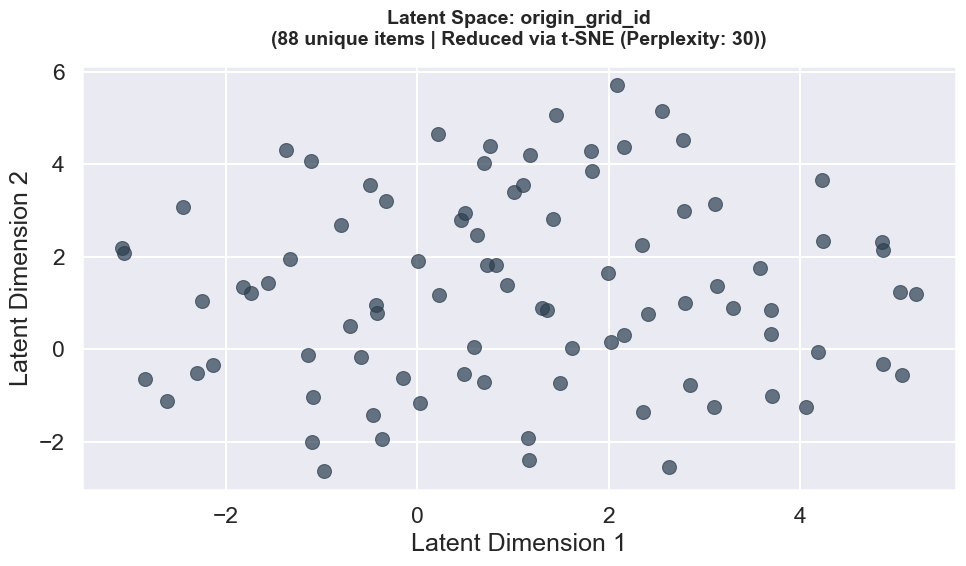

------------------------------------------------------------
📊 Generating layout for: vehicle_type_id...


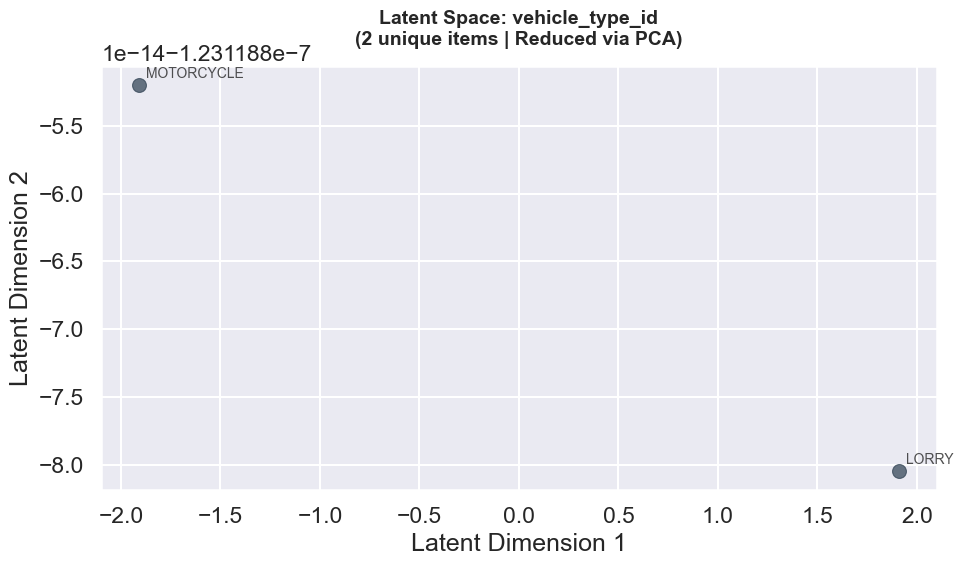

------------------------------------------------------------
📊 Generating layout for: location_type...


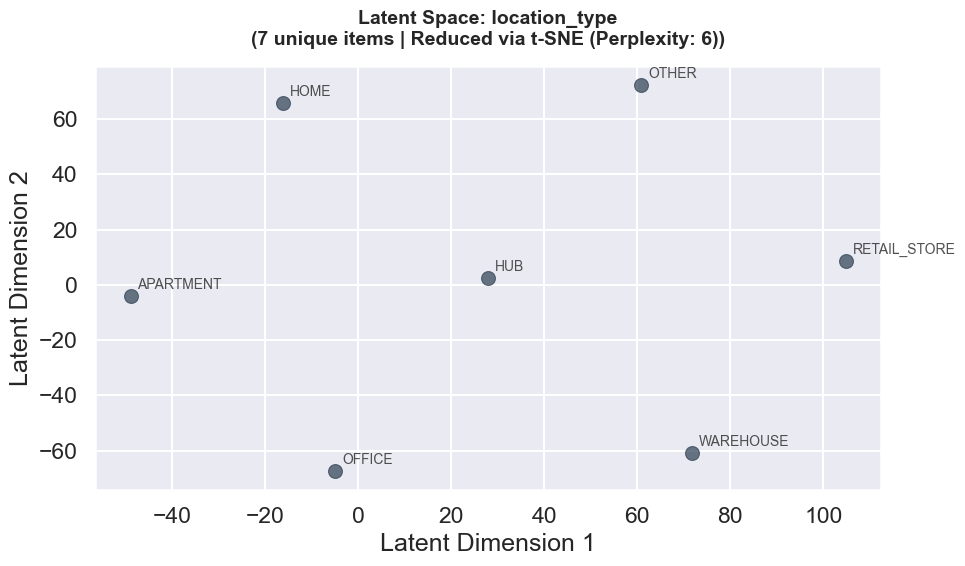

------------------------------------------------------------
📊 Generating layout for: prev_location_type...


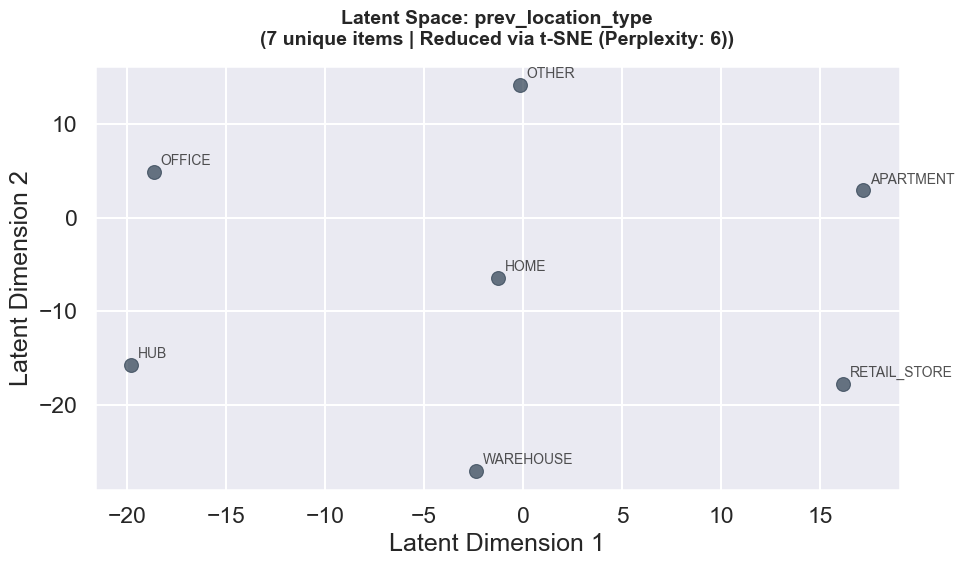

------------------------------------------------------------
📊 Generating layout for: is_pin_verified...


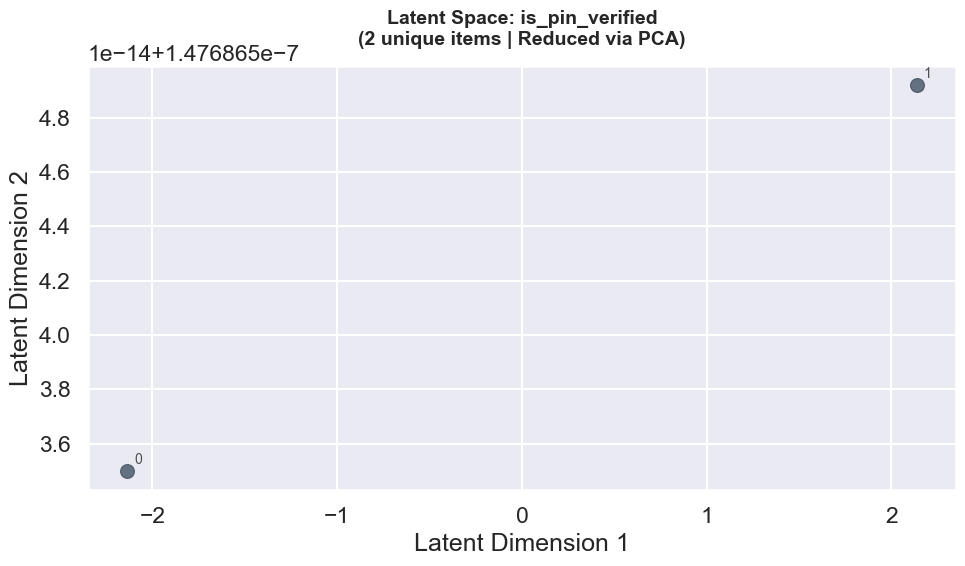

------------------------------------------------------------
📊 Generating layout for: weather_code...


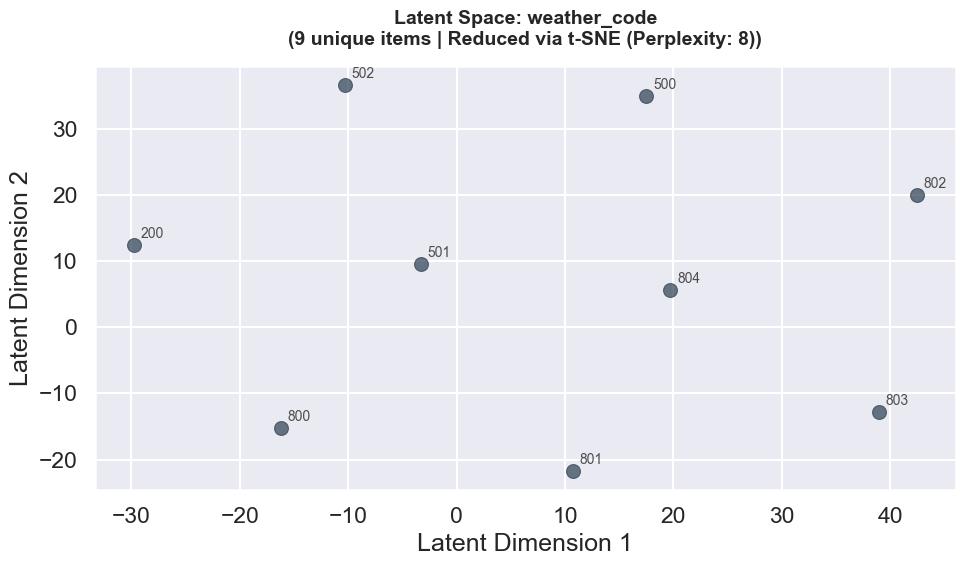

------------------------------------------------------------
📊 Generating layout for: month_of_year...


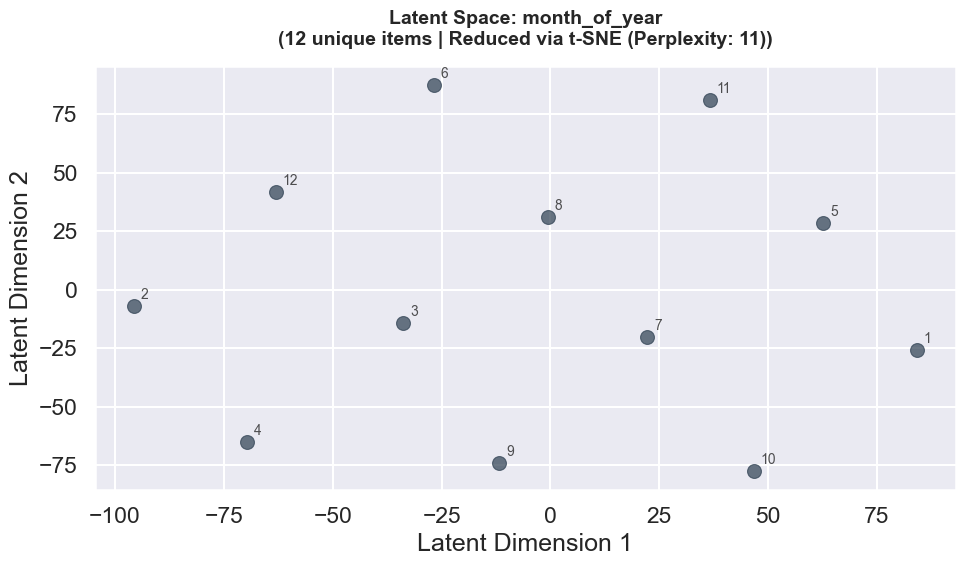

------------------------------------------------------------
📊 Generating layout for: day_of_week...


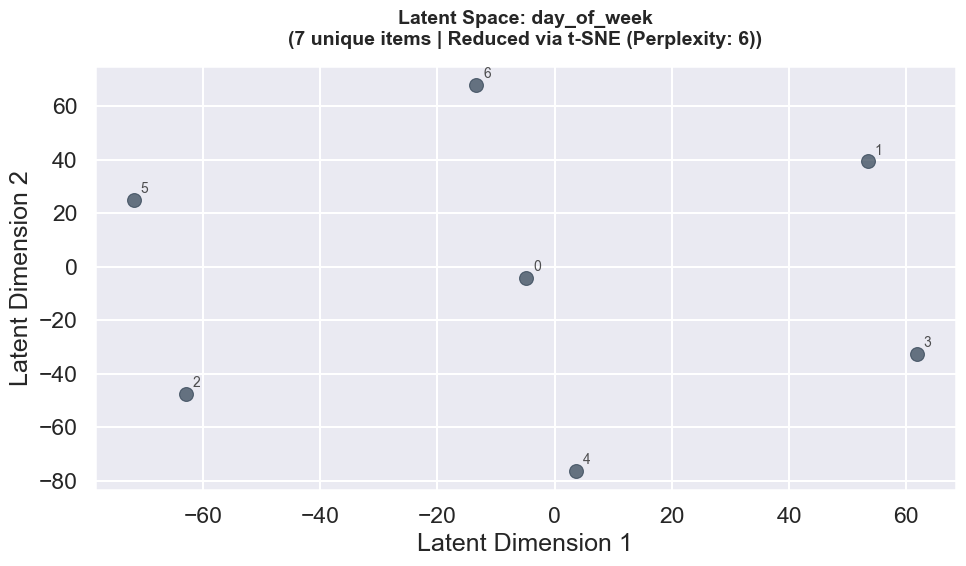

------------------------------------------------------------
📊 Generating layout for: hour_of_day...


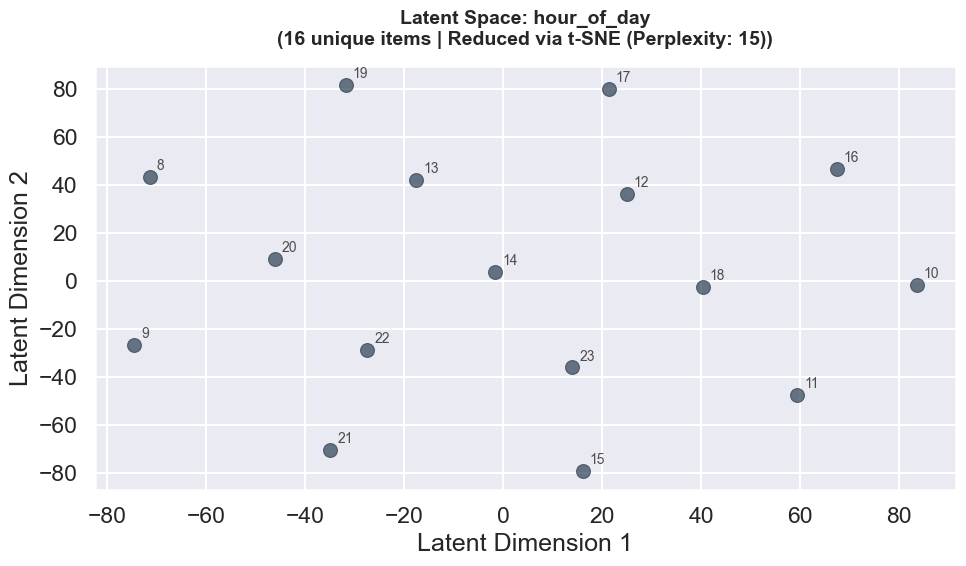

------------------------------------------------------------
📊 Generating layout for: prev_cod_friction_code...


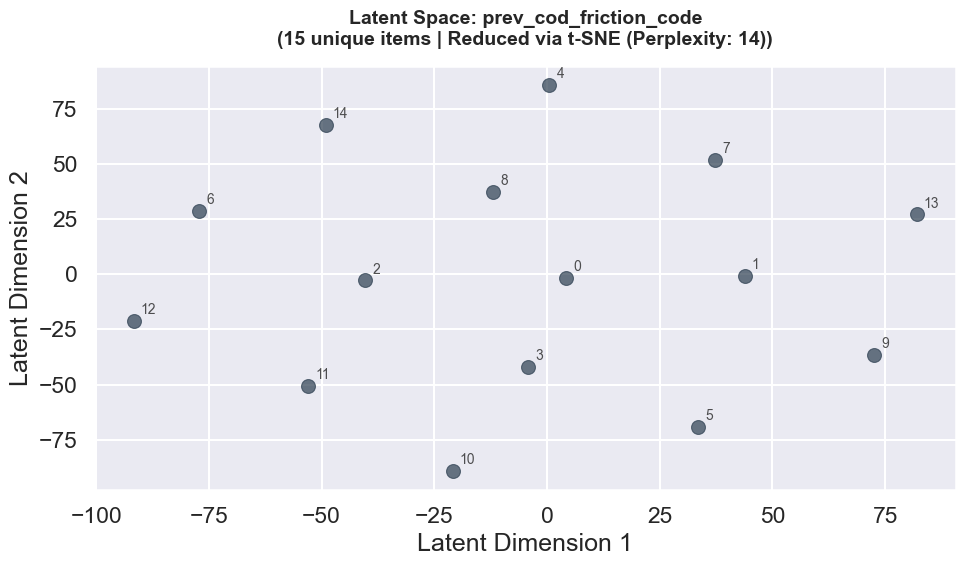

------------------------------------------------------------
📊 Generating layout for: trip_sequence_id...


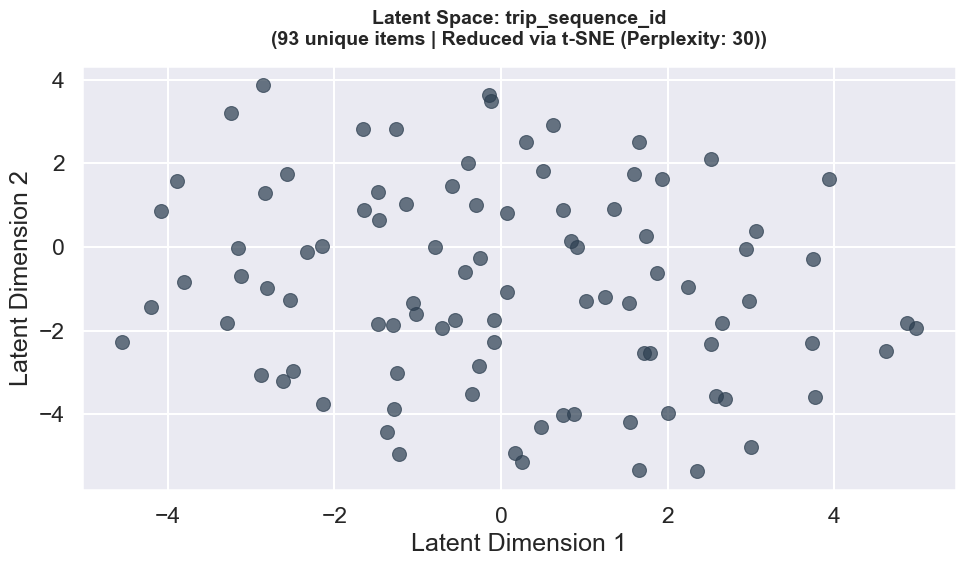

------------------------------------------------------------
📊 Generating layout for: trip_progress_id...


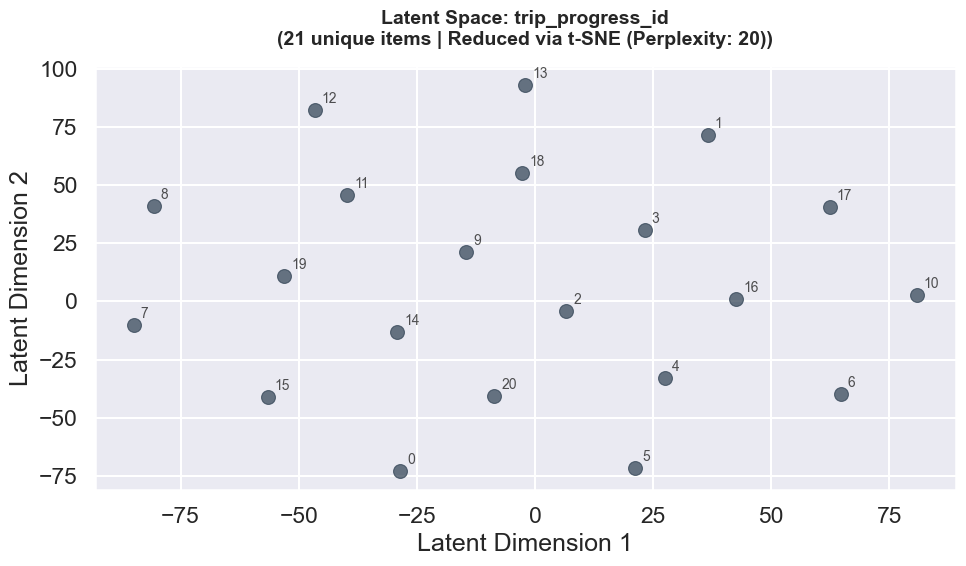

------------------------------------------------------------


In [2]:
# ==========================================
# 2. EXTRACT & VISUALIZE LATENT EMBEDDINGS
# ==========================================

sparse_features = [
    'driver_id', 'prev_customer_id', 'customer_id', 'destination_grid_id',
    'origin_grid_id', 'vehicle_type_id', 'location_type', 'prev_location_type',
    'is_pin_verified', 'weather_code', 'month_of_year', 'day_of_week',
    'hour_of_day', 'prev_cod_friction_code', 'trip_sequence_id', 'trip_progress_id'
]

print("🧠 Extracting memories from the Local DeepFM Brain...\n")

# Navigate up one folder, then into models/
# Note: Using your Local weights file based on your tree
weights_path = '../models/lamigo_deepfm_weights_Local.pth' 
state_dict = torch.load(weights_path, map_location='cpu', weights_only=True)

def plot_latent_space(feature_name):
    weight_key = f'embeddings.{feature_name}.weight'
    
    if weight_key not in state_dict:
        print(f"⚠️ Warning: Could not find weights for {feature_name}. Skipping.")
        return
        
    emb_matrix = state_dict[weight_key].numpy()
    
    # Direct relative path to the metadata folder
    le_path = f'../models/metadata/le_{feature_name}.joblib'
    
    try:
        le = joblib.load(le_path)
    except FileNotFoundError:
        print(f"⚠️ Warning: Could not find {le_path}. Skipping.")
        return
        
    classes = le.classes_
    n_items = len(classes)
    
    emb_matrix = emb_matrix[:n_items, :]
    
    # Dimensionality Reduction
    if n_items < 5:
        reducer = PCA(n_components=2, random_state=42)
        algorithm_used = "PCA"
    else:
        perplexity = min(30, n_items - 1)
        reducer = TSNE(n_components=2, perplexity=perplexity, random_state=42, init='pca', learning_rate='auto')
        algorithm_used = f"t-SNE (Perplexity: {perplexity})"
        
    reduced_emb = reducer.fit_transform(emb_matrix)
    
    # Visualization
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=reduced_emb[:, 0], y=reduced_emb[:, 1], 
                    alpha=0.7, color='#2c3e50', edgecolor=None, s=100)
    
    if n_items <= 50:
        for i, txt in enumerate(classes):
            plt.annotate(str(txt), 
                         (reduced_emb[i, 0], reduced_emb[i, 1]),
                         xytext=(5, 5), textcoords='offset points',
                         fontsize=10, alpha=0.8)
            
    plt.title(f'Latent Space: {feature_name}\n({n_items} unique items | Reduced via {algorithm_used})', 
              fontsize=14, pad=15, fontweight='bold')
    plt.xlabel("Latent Dimension 1")
    plt.ylabel("Latent Dimension 2")
    plt.tight_layout()
    plt.show()

for feature in sparse_features:
    print(f"📊 Generating layout for: {feature}...")
    plot_latent_space(feature)
    print("-" * 60)